In [3]:
# Import necessary libraries
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Ensure output folder exists for all exported figures
FIG_DIR = Path("Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
# Part 1: Download data

In [ ]:
copernicusmarine.subset(
    dataset_id="cmems_mod_arc_phy_my_topaz4_P1M",
    variables=["mlotst", "siconc", "sisnthick", "so", "thetao", "vxsi", "vysi"],
    # minimum_longitude=-5.0,
    # maximum_longitude=36.0,
    # minimum_latitude=30.0,
    # maximum_latitude=46.0,
    start_datetime="2015-01-01T00:00:00",
    end_datetime="2016-12-31T23:59:59",
    output_directory="Data",
    output_filename="cmems_arctic_2015-2016.nc",
    force_download=True
)

: 

: 

: 

---
# Part 2: Data Investigation

The geophysical fields in the dataset:
1. **mlotst:** Ocean mixed layer thickness [m]
2. **siconc:** Sea-ice concentration (fraction/percent of ocean area covered by ice) [%]
3. **sisnthick:** Snow thickness on sea ice [m]
4. **so:** Sea-water salinity (practical salinity or equivalent model salinity units)
5. **thetao:** Sea-water potential temperature [degK]
6. **vxsi:** Sea-ice velocity in x/eastward model direction [m/s]
7. **vysi:** Sea-ice velocity in y/northward model direction [m/s]


In [4]:
# Load the dataset
ds = xr.open_dataset("Data/cmems_arctic_2015-2016.nc")

In [5]:
# Variable name mapping with units for clearer graph titles/labels
var_names = {
    'mlotst': 'Mixed Layer Depth (m)',
    'siconc': 'Sea Ice Concentration (%)',
    'sisnthick': 'Snow Thickness on Sea Ice (m)',
    'so': 'Sea-water Salinity (psu)',
    'thetao': 'Sea-water Temperature (degC)',
    'vxsi': 'Sea-ice Velocity (x-direction, m/s)',
    'vysi': 'Sea-ice Velocity (y-direction, m/s)'
}

# ==== Standardize dataset units once so all following analysis uses the same units ====

# Convert sea-ice concentration from fraction [0, 1] to percent [%] when needed
siconc_max = float(ds['siconc'].max(skipna=True).values)
if siconc_max <= 1.01:
    ds['siconc'] = ds['siconc'] * 100.0
    ds['siconc'].attrs['units'] = '%'

# Convert temperature from Kelvin to degree Celsius when needed
thetao_mean = float(ds['thetao'].mean(skipna=True).values)
if thetao_mean > 100.0:
    ds['thetao'] = ds['thetao'] - 273.15
    ds['thetao'].attrs['units'] = 'degC'

---
# Part 3: Variable Map Distribution

In [6]:
# Extract a single time slice
sst_day_one = ds['mlotst'].isel(time=0) # time index 0 = time step in the dataset = January 1, 2015

# General function for plotting a variable map disturibution
def plot_variable_map(ds, variable, time_sel, depth_sel=None):
    """Plot a 2D map of a dataset variable for a selected date/time index."""

    # Get full variable name
    var_full_name = var_names.get(variable, variable)
    title = f"{var_full_name} on {time_sel}"

    # Select the variable and the time slice
    da = ds[variable]
    da_plot = da.sel(time=np.datetime64(time_sel), method='nearest')

    # Depth handling
    if 'depth' in da_plot.dims:
        title += f' at depth {depth_sel} m'
        if depth_sel is not None:
            da_plot = da_plot.isel(depth=depth_sel)
        else:
            da_plot = da_plot.isel(depth=0)  # Select the surface layer

    # Set up the plot
    plt.figure(figsize=(11,4))
    da_plot.plot(cmap='viridis', cbar_kwargs={'label': var_full_name})

    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()

    # Save first, then show, to avoid blank exported images in some backends
    safe_time = str(time_sel).replace(':', '-').replace(' ', '_')
    plt.savefig(FIG_DIR / f"Variable_Map_{variable}_{safe_time}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    return


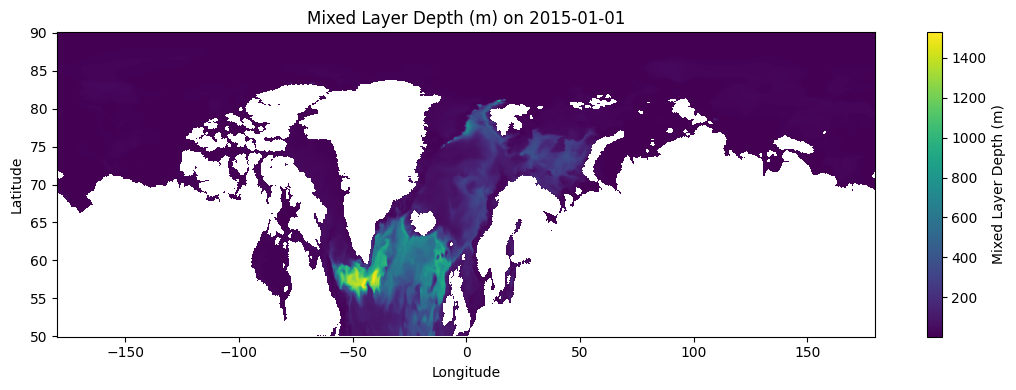

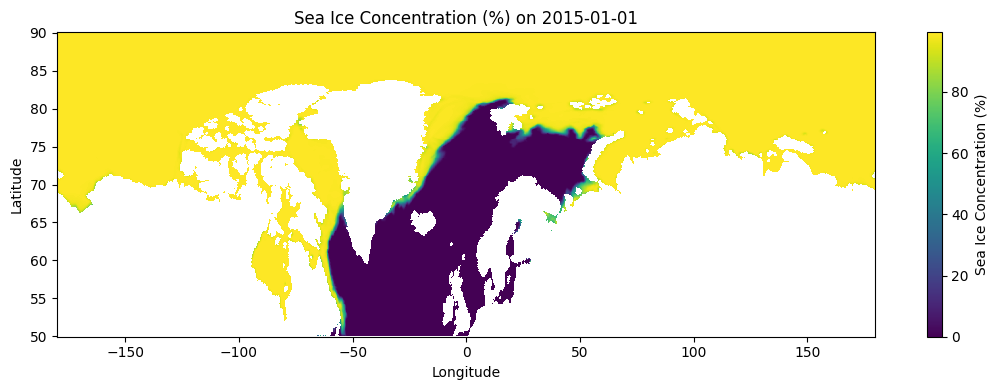

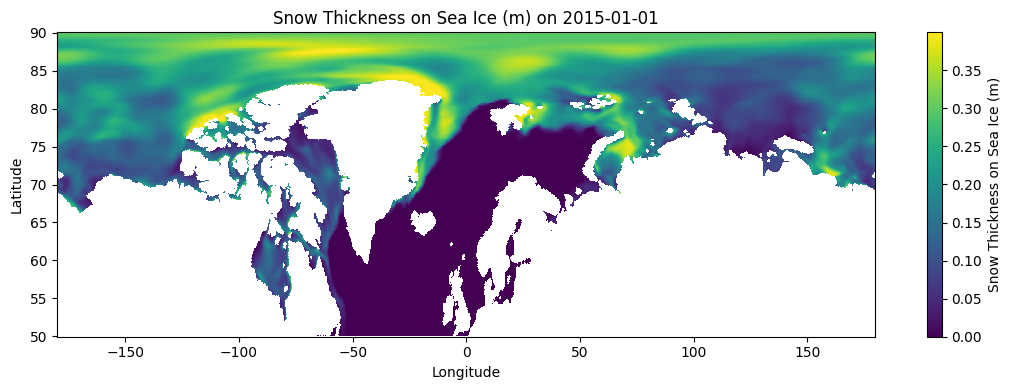

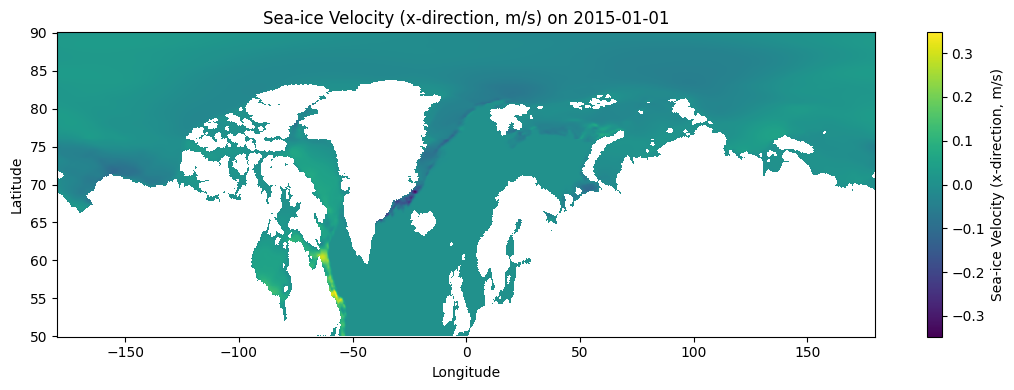

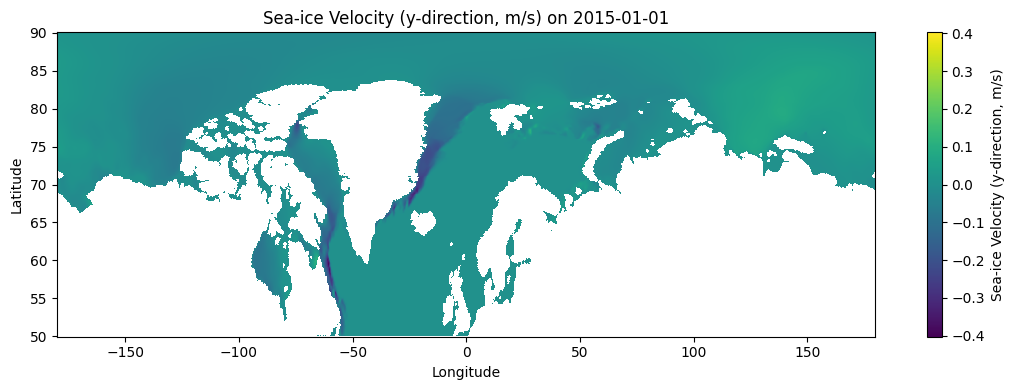

In [7]:
# ===== Maps for all variables on January 1, 2015 ====== 
plot_variable_map(ds, variable='mlotst', time_sel='2015-01-01')
plot_variable_map(ds, variable='siconc', time_sel='2015-01-01')
plot_variable_map(ds, variable='sisnthick', time_sel='2015-01-01')
plot_variable_map(ds, variable='vxsi', time_sel='2015-01-01')
plot_variable_map(ds, variable='vysi', time_sel='2015-01-01')

For the next two graph the depth has to be specified.

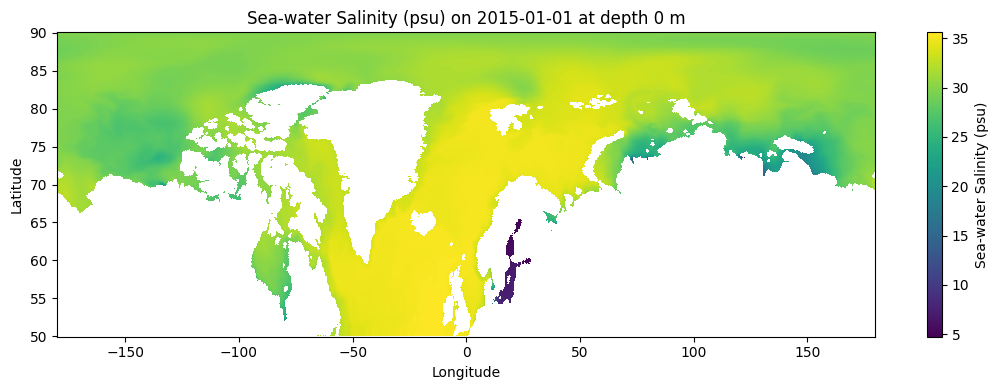

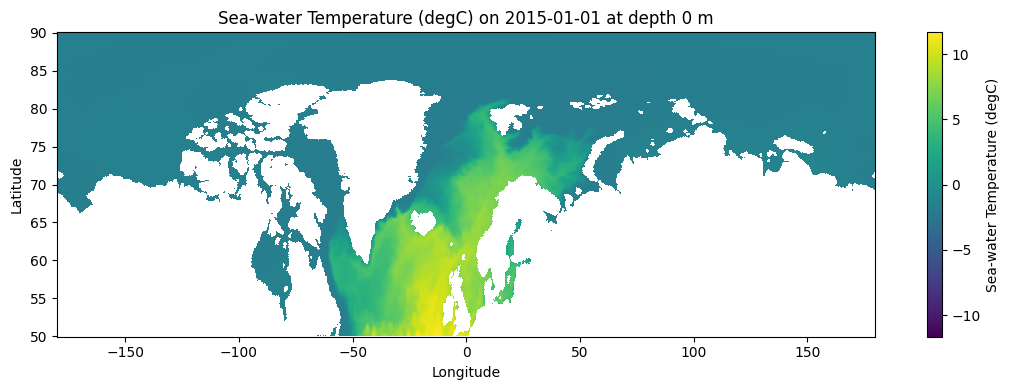

In [8]:
# ===== Maps for all variables requiring depth selection on January 1, 2015 ====== 
plot_variable_map(ds, variable='so', time_sel='2015-01-01', depth_sel=0)
plot_variable_map(ds, variable='thetao',time_sel='2015-01-01', depth_sel=0)

## <span style="color:#ED551A;">Takeaways!</span>
The **Sea-water Salinity** graph and **Sea-water Potential Temperature** graph depend on the `time`, `latitude`, `longitute` as the other variables but also on the `depth` therefore a specific value had to be picked insted of having a surface value analyzed. 


---
# Part 4: Mean and Standard Deviation Maps of Variables

In [9]:
def plot_mean_std_maps(ds,variable, depth_sel=None):
    """ Compute and plot time-mean and time-std maps for one variable."""

    # Get full variable name
    var_full_name = var_names.get(variable, variable)

    # Select the variable
    da = ds[variable]

    # Depth handling
    if 'depth' in da.dims:
        if depth_sel is None:
            depth_sel = float(da['depth'].isel(depth=0).values)
        da = da.sel(depth=depth_sel, method='nearest')
        print(f"{var_full_name}: using depth={float(da['depth'].values):.2f}")

    # Compute time mean and std, skip the NaN values
    da_mean = da.mean(dim='time', skipna=True)
    da_std = da.std(dim='time', skipna=True)

    fig, axes = plt.subplots(2, 1, figsize=(11, 8))

    # Plot the mean graph
    da_mean.plot(
        ax=axes[0],
        cmap='viridis',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[0].set_title(f"{var_full_name}: Time Mean (2015-2016)")
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    # Plot the STD graph
    da_std.plot(
        ax=axes[1],
        cmap='magma',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[1].set_title(f"{var_full_name}: Time Std (2015-2016)")
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

    plt.tight_layout()

    # Save first, then show, to avoid blank exported images in some backends
    depth_tag = 'surface' if depth_sel is None else depth_sel
    plt.savefig(FIG_DIR / f"Mean_STD_Maps_{variable}_Depth{depth_tag}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    return
    

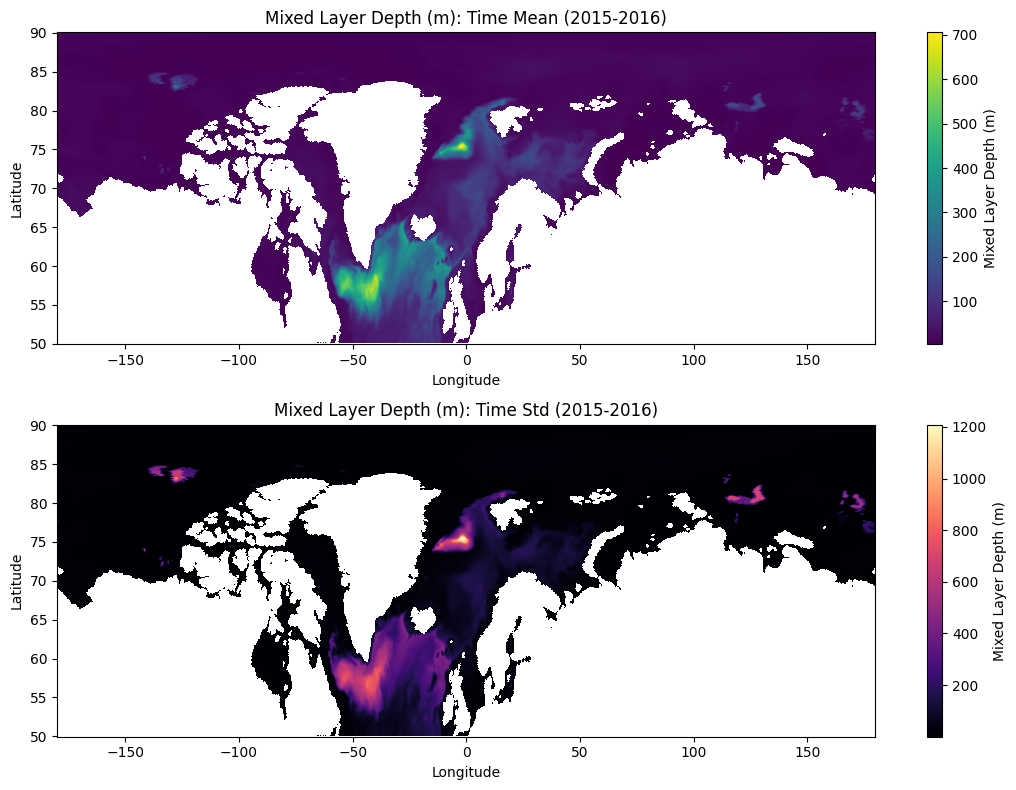

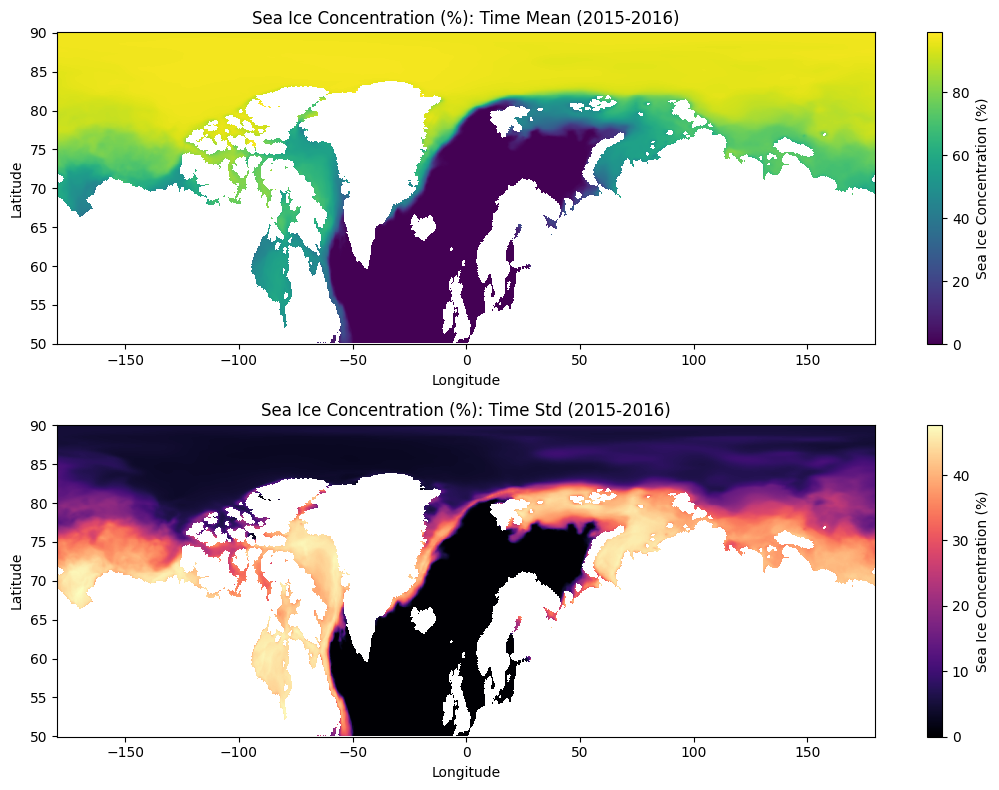

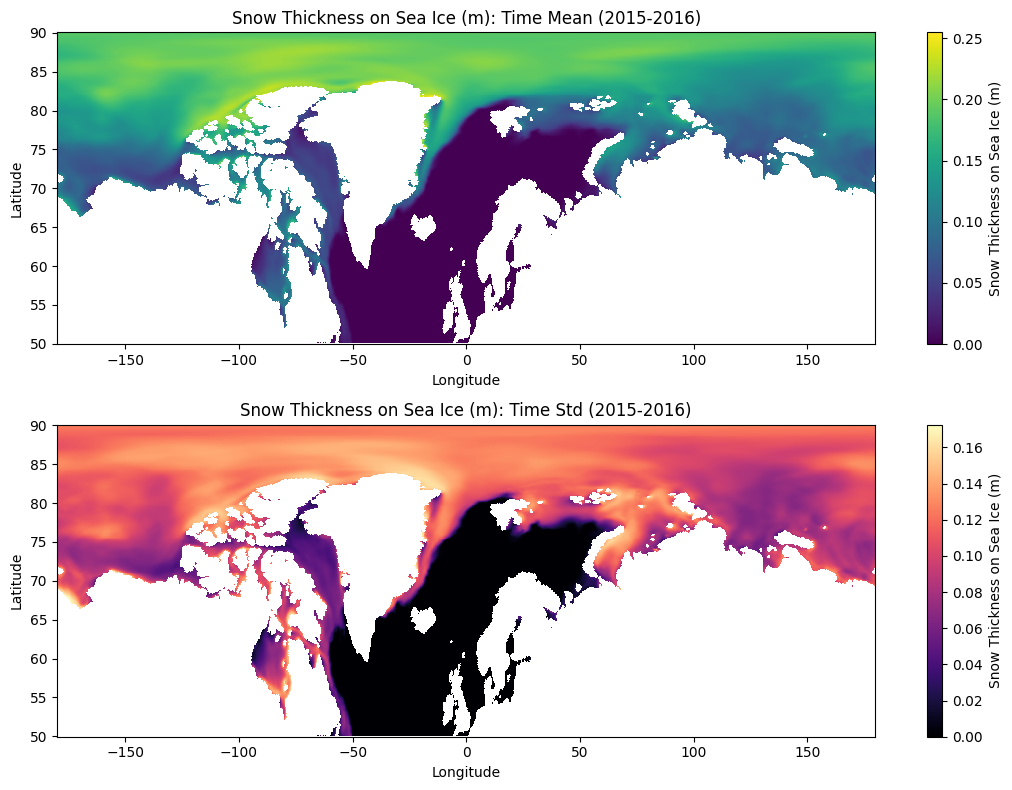

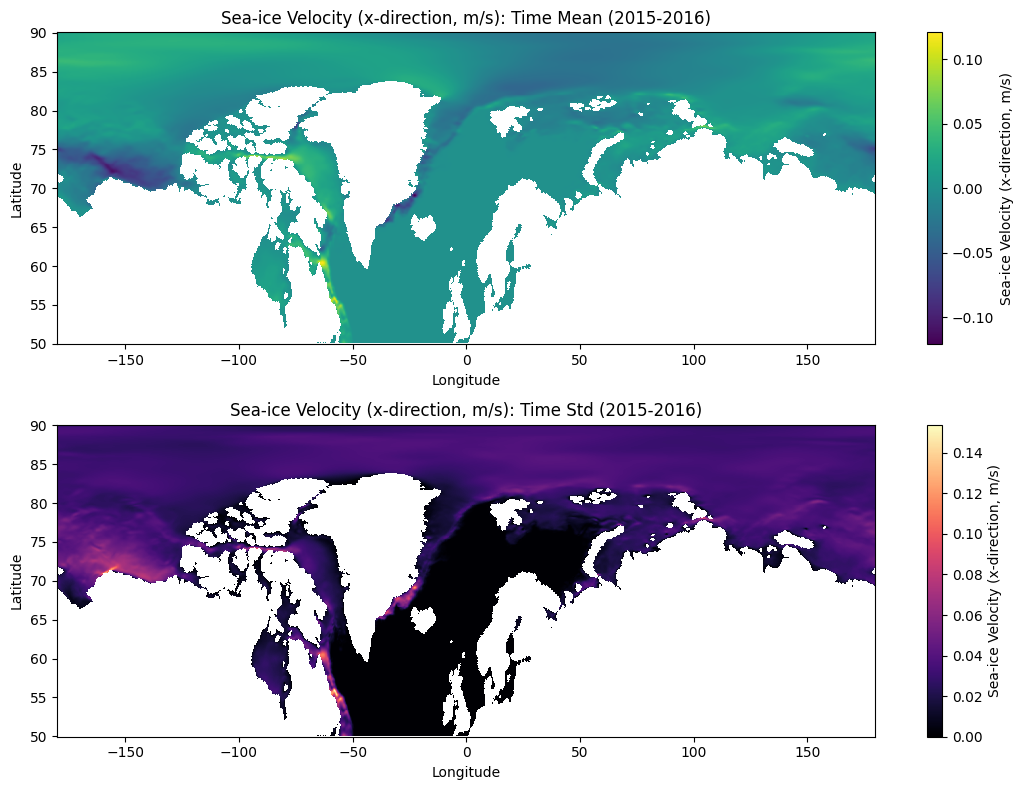

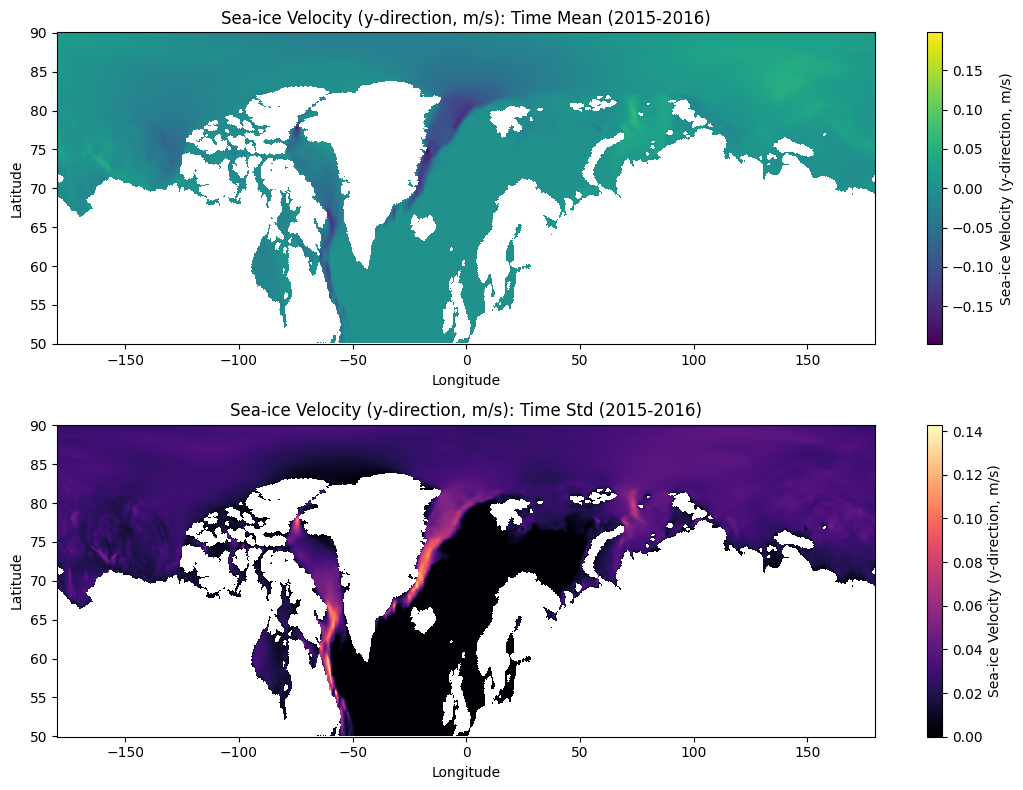

Sea-water Salinity (psu): using depth=0.00


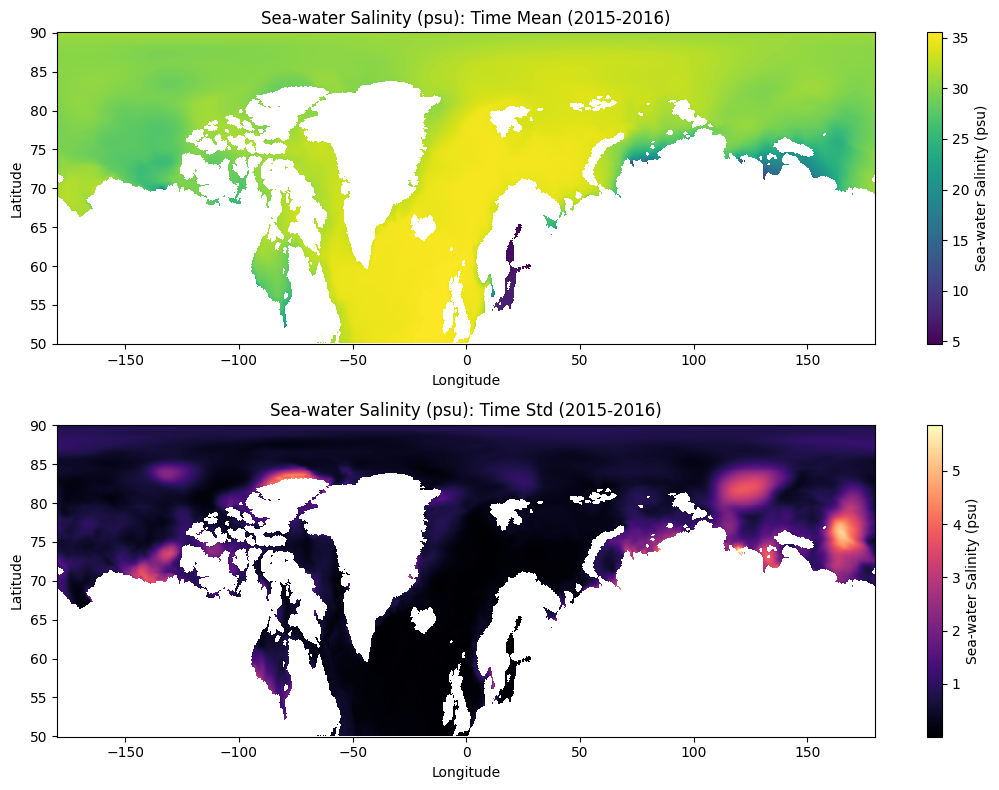

Sea-water Temperature (degC): using depth=0.00


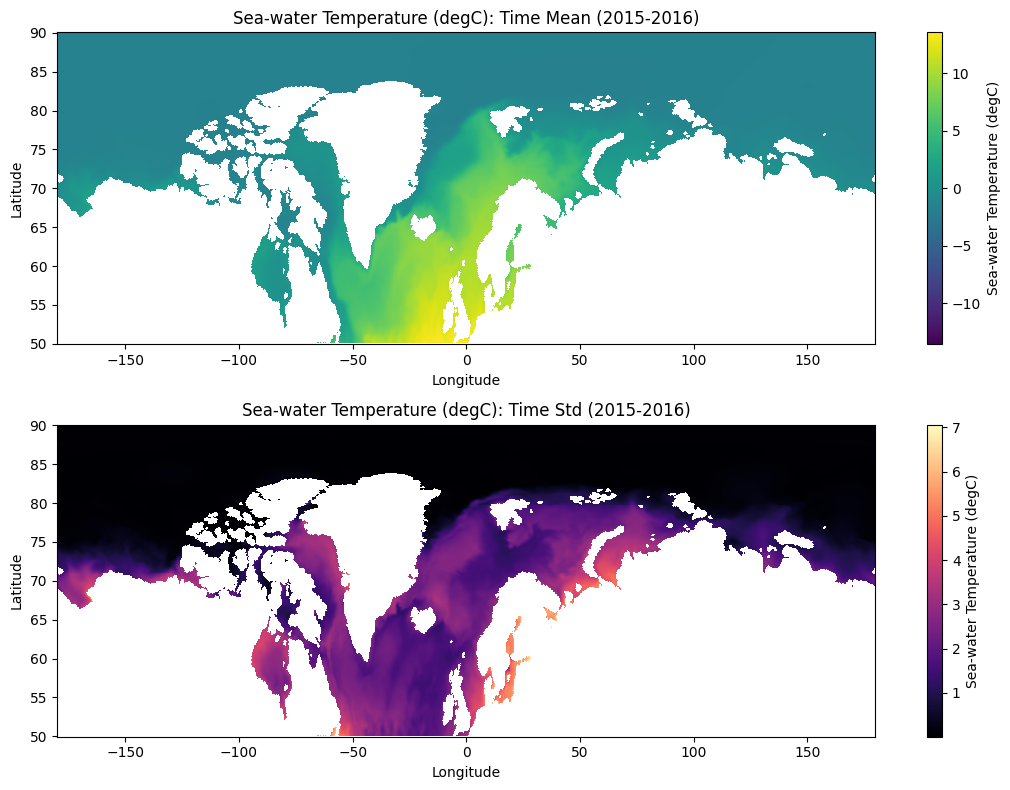

In [10]:
# ====== Mean and Std Maps for all variables ======

plot_mean_std_maps(ds, 'mlotst')
plot_mean_std_maps(ds, 'siconc')
plot_mean_std_maps(ds, 'sisnthick')
plot_mean_std_maps(ds, 'vxsi')
plot_mean_std_maps(ds, 'vysi')

# Depth-dependent variables: choose surface level (or change depth_sel).
plot_mean_std_maps(ds, 'so', depth_sel=0)
plot_mean_std_maps(ds, 'thetao', depth_sel=0)

## <span style="color:#ED551A;">Takeaways!</span>
Describe what is on the graphs

---
# Part 5: Temporal Variability

Our group have decide to focus a bit more on the Labrador Sea beacause there are different currents mixing in the area.

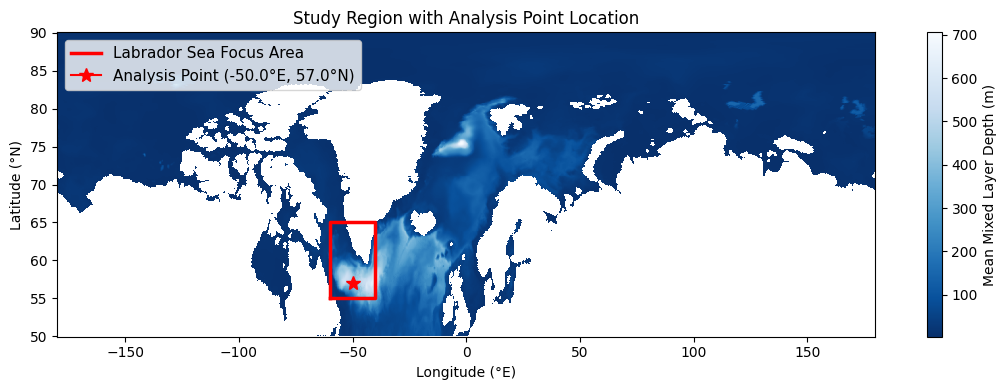

In [11]:
# ===== Plot the study region with the analysis point marked ======

def plot_study_region(ds, lon_point=-50.0, lat_point=57.0):
    """ Plot the study region from the dataset with the analysis point marked. """
    
    region_bounds = {'lon_min': -60, 'lon_max': -40, 'lat_min': 55, 'lat_max': 65}
    
    # Get mean sea ice concentration as background
    mlotst_mean = ds['mlotst'].mean(dim='time', skipna=True)
    
    plt.figure(figsize=(11, 4))
    
    # Plot background variable as context
    mlotst_mean.plot(cmap='Blues_r', cbar_kwargs={'label': 'Mean Mixed Layer Depth (m)'})
    
    # Plot Labrador Sea region box
    rect_lon = [region_bounds['lon_min'], region_bounds['lon_max'], 
                region_bounds['lon_max'], region_bounds['lon_min'], 
                region_bounds['lon_min']]
    rect_lat = [region_bounds['lat_min'], region_bounds['lat_min'], 
                region_bounds['lat_max'], region_bounds['lat_max'], 
                region_bounds['lat_min']]
    plt.plot(rect_lon, rect_lat, 'r-', linewidth=2.5, label='Labrador Sea Focus Area')
    
    # Mark the analysis point
    plt.plot(lon_point, lat_point, marker='*', markersize=10, color='red', 
             label=f'Analysis Point ({lon_point}°E, {lat_point}°N)', zorder=5)
    
    plt.xlabel('Longitude (°E)')
    plt.ylabel('Latitude (°N)')
    plt.title('Study Region with Analysis Point Location')
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()

    plt.savefig(FIG_DIR / "Study_Region_Map.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    return

# Plot the study region
plot_study_region(ds, lon_point=-50.0, lat_point=57.0)

In [12]:
def plot_temporal_variability_area(ds, variable, lon_min, lon_max, lat_min, lat_max):
    """ Plot area-averaged temporal variability for a selected lon/lat box. """

    # Get full variable name for titles/labels
    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # Get the spatial subset for the selected box
    lon_slice = slice(lon_min, lon_max)
    lat_slice = slice(lat_min, lat_max)
    da_area = da.sel(longitude=lon_slice, latitude=lat_slice).copy(deep=True)

    # Handle depth-dependent variables so result is always a 1D time series
    if 'depth' in da_area.dims:
        da_area = da_area.isel(depth=0)     # Select the surface layer
        var_full_name = f"{var_full_name} (surface)"

    # Area average for each timestamp!!!
    ts = da_area.mean(dim=['latitude', 'longitude'], skipna=True) # Skip empty points

    fig, ax = plt.subplots(figsize=(12, 4.2), dpi=120)
    ax.plot(ts['time'].values, ts.values, color="#227FD5", linewidth=2.0, marker='o', markersize=4)

    # Calculate and display mean, min, max values on the plot
    mean_v = float(np.nanmean(ts.values))
    min_v = float(np.nanmin(ts.values))
    max_v = float(np.nanmax(ts.values))
    std_v = float(np.nanstd(ts.values))
    ax.text(0.01, 0.98, f"Mean={mean_v:.2f}\nMin={min_v:.2f}\nMax={max_v:.2f}\nSTD={std_v:.2f}", transform=ax.transAxes, 
            va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'))

    ax.set_title(f"Area-Mean Time Series: {var_full_name} ")
    ax.set_xlabel('Time')
    ax.set_ylabel(var_full_name)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(frameon=False, loc='best')

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"Temporal_Variability_{variable}_Area.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    return ts

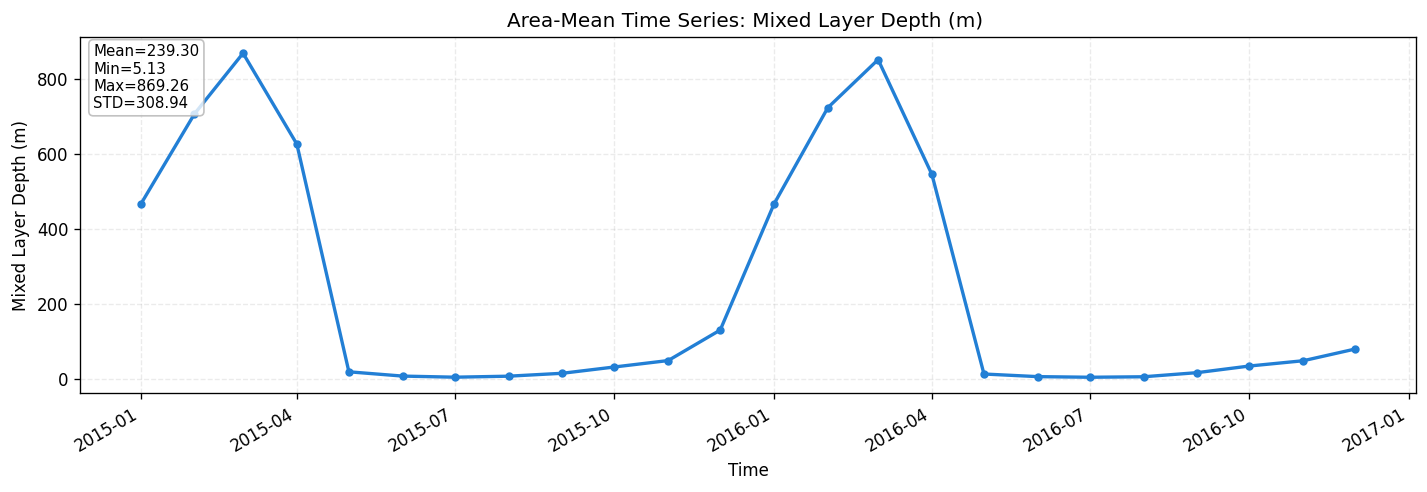

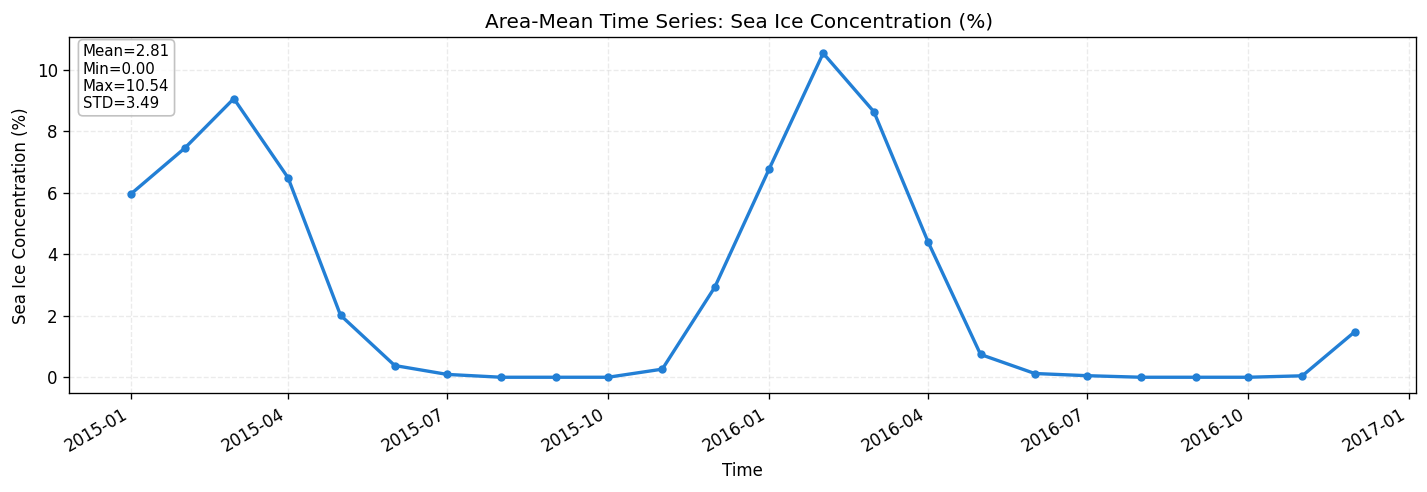

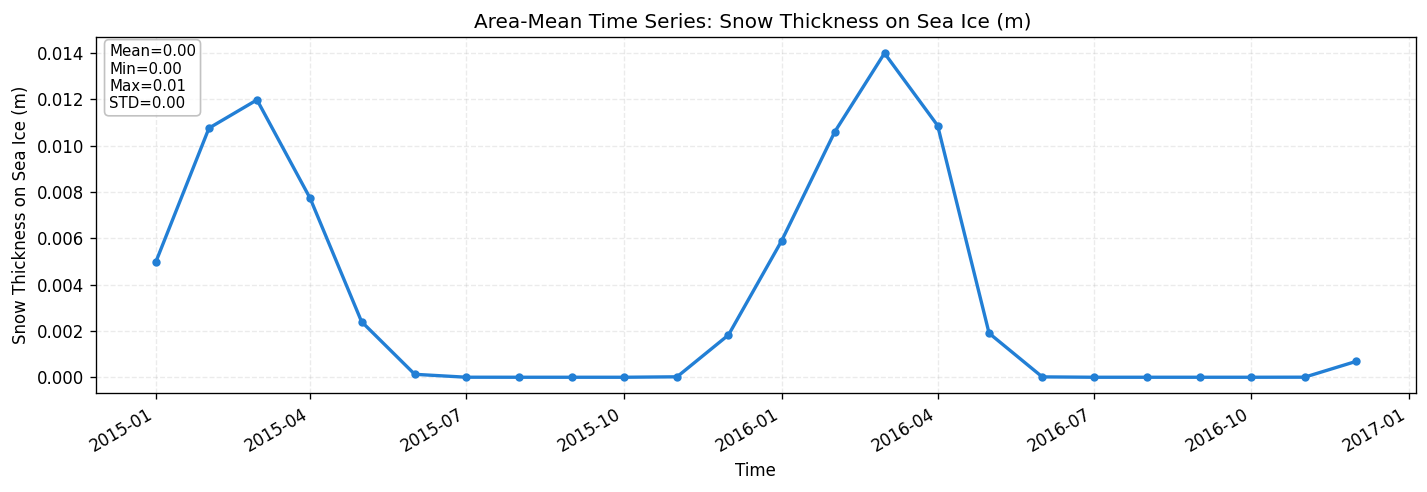

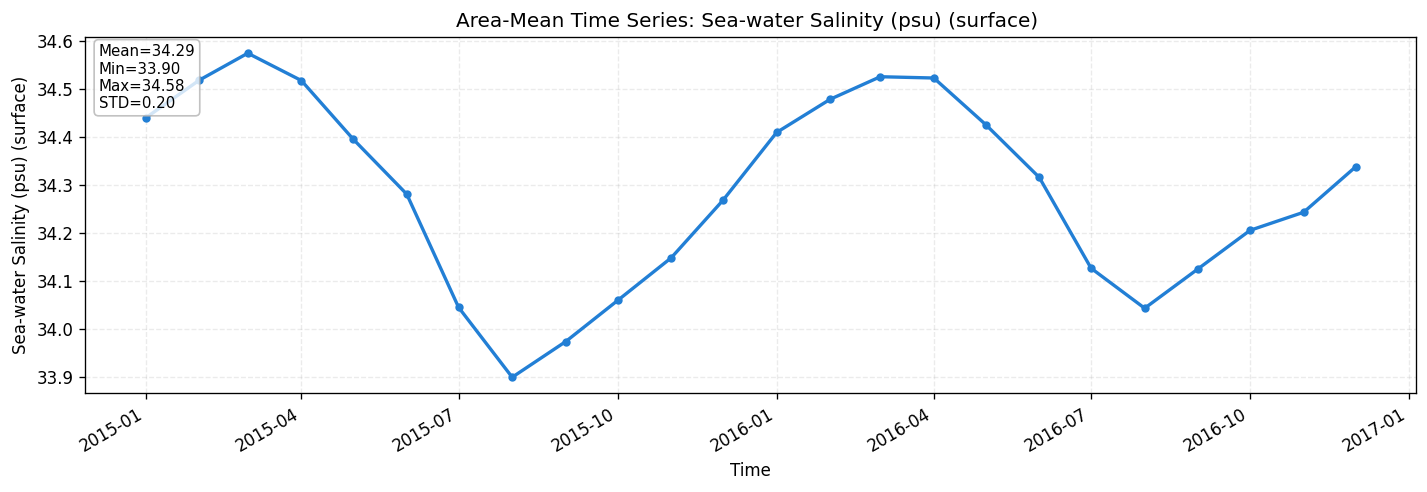

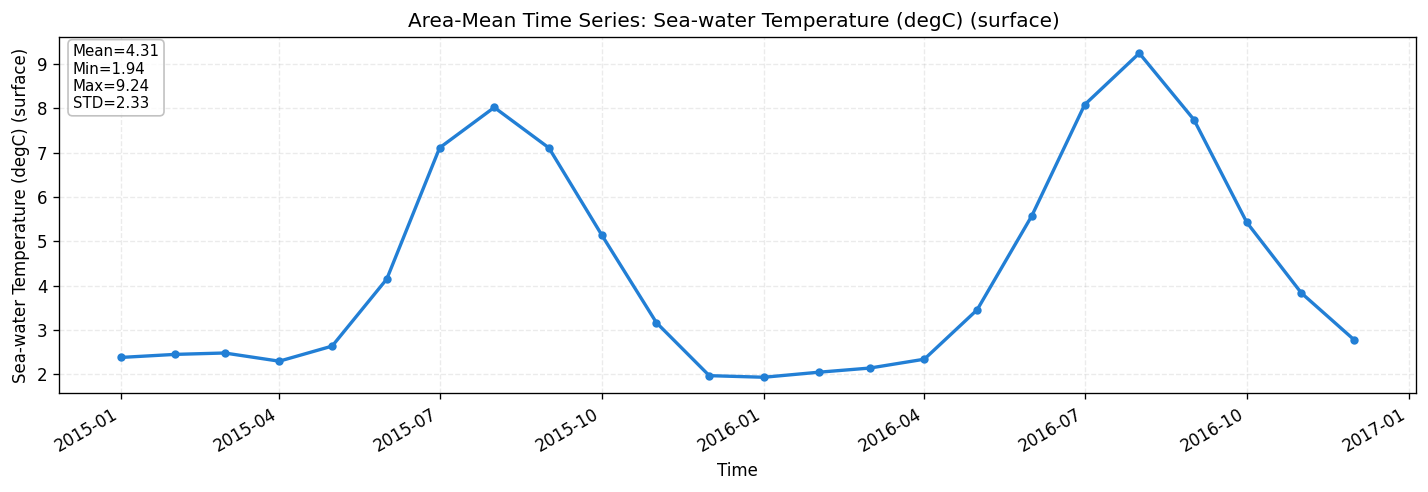

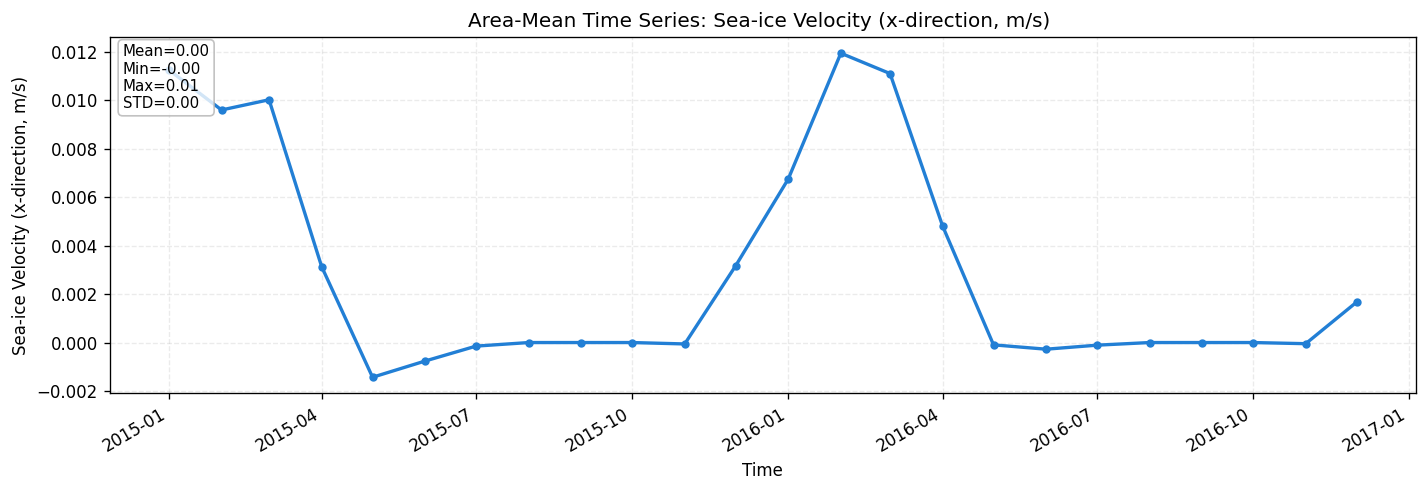

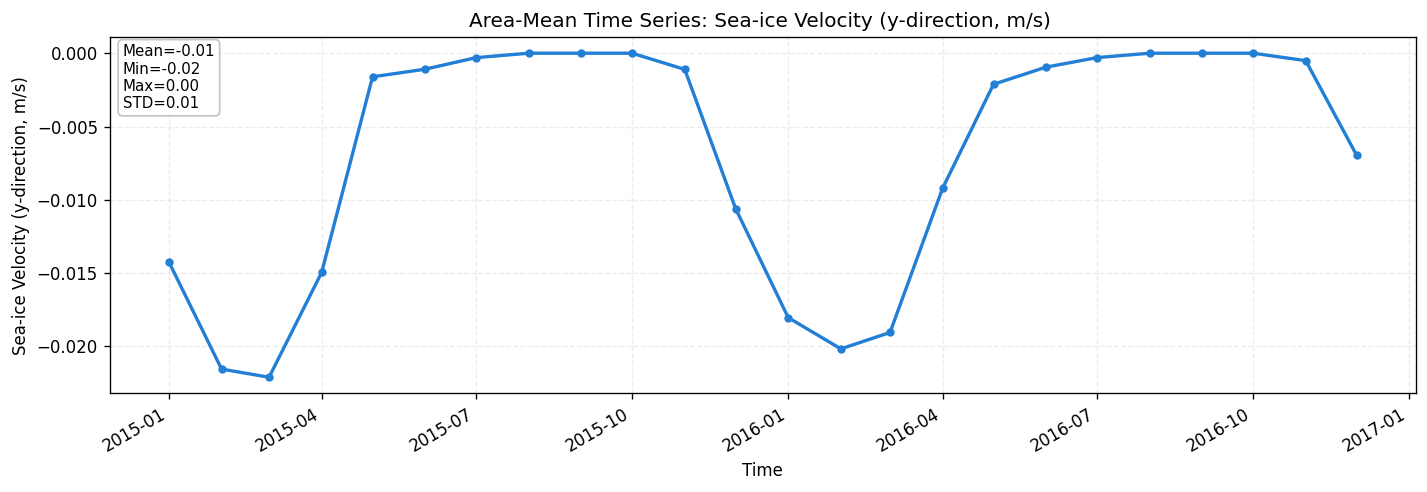

In [13]:
# Selected Area (Labrador Sea)
LON_MIN, LON_MAX = -60.0, -40.0
LAT_MIN, LAT_MAX = 55.0, 65.0

# Plot area-mean temporal variability for all parameters
for variable in var_names.keys():
    plot_temporal_variability_area(ds, variable, LON_MIN, LON_MAX, LAT_MIN, LAT_MAX)

## <span style="color:#ED551A;">Takeaways!</span>
Describe what is on the graphs

---
# Part 6: Spatial Distribution

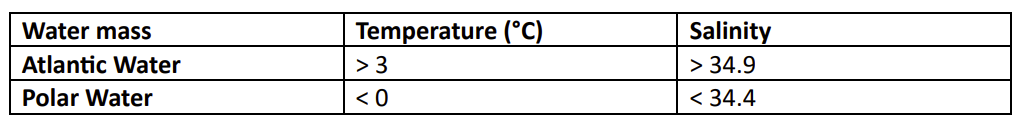

In [14]:
# Pre-defined thresholds

ATLANTIC = {
    'salinity_min': 34.9,   # psu
    'temp_min_c': 3.0       # degC
}
POLAR = {
    'salinity_max': 34.4,   # psu
    'temp_max_c': 0.0       # degC
}

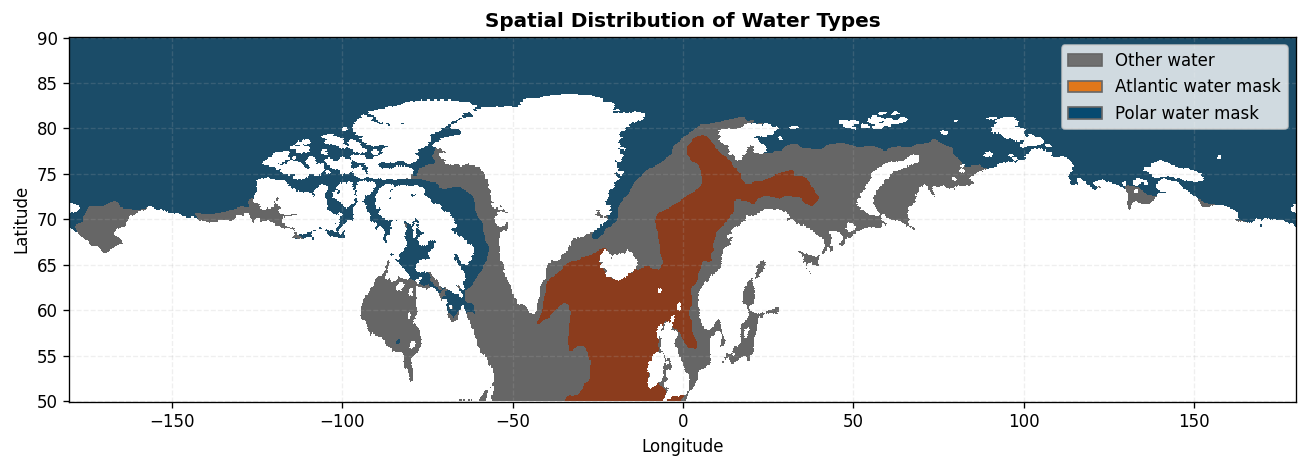

Mean-state area coverage statistics:
Atlantic Water mean-state area coverage: 4.9%
Polar Water mean-state area coverage: 34.5%
Other Water mean-state area coverage: 10.1%


In [15]:
# Select surface layer data
so_surf = ds['so'].isel(depth=0).copy(deep=True)
thetao_surf = ds['thetao'].isel(depth=0).copy(deep=True)

# Mean-state classification maps (average over time)
so_mean = so_surf.mean(dim='time', skipna=True)
thetao_mean = thetao_surf.mean(dim='time', skipna=True)

# Create the limits for different waters
atlantic_mean_mask = ((so_mean >= ATLANTIC['salinity_min']) & (thetao_mean >= ATLANTIC['temp_min_c'])).astype(float)
polar_mean_mask = ((so_mean <= POLAR['salinity_max']) & (thetao_mean <= POLAR['temp_max_c'])).astype(float)

# Coverage: where there is land
coverage = so_surf.notnull().any(dim='time')

# "Other water" = covered ocean points that are neither Atlantic nor Polar
other_water_mask = ((atlantic_mean_mask == 0) & (polar_mean_mask == 0) & coverage).astype(float)

# Keep only 1-values for clean overlay plotting 
other_plot = other_water_mask.where(other_water_mask == 1)
atl_plot = atlantic_mean_mask.where(atlantic_mean_mask == 1)
pol_plot = polar_mean_mask.where(polar_mean_mask == 1)

fig, ax = plt.subplots(figsize=(11, 4), dpi=120)

# Base: other water in gray
other_plot.plot(
    ax=ax,
    cmap='Greys',
    vmin=0, vmax=1, alpha=0.6,
    add_colorbar=False
)

# Overlay Atlantic and Polar masks
atl_plot.plot(
    ax=ax,
    cmap='Oranges',
    vmin=0, vmax=1, alpha=0.9,
    add_colorbar=False
)
pol_plot.plot(
    ax=ax,
    cmap='PuBu',
    vmin=0, vmax=1, alpha=0.9,
    add_colorbar=False
)

# Add a manual legend for categories
legend_handles = [
    Patch(facecolor="#6f6f6f", edgecolor='0.4', label='Other water'),
    Patch(facecolor="#e0771a", edgecolor='0.4', label='Atlantic water mask'),
    Patch(facecolor="#074a70", edgecolor='0.4', label='Polar water mask')
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True)

ax.set_title('Spatial Distribution of Water Types', fontsize=12, weight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()

plt.savefig(FIG_DIR / "Water_Type_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Coverage statistics
atlantic_area_frac = float((atlantic_mean_mask == 1).mean(skipna=True).values) * 100
polar_area_frac = float((polar_mean_mask == 1).mean(skipna=True).values) * 100
other_area_frac = float((other_water_mask == 1).mean(skipna=True).values) * 100
print("Mean-state area coverage statistics:")
print(f"Atlantic Water mean-state area coverage: {atlantic_area_frac:.1f}%")
print(f"Polar Water mean-state area coverage: {polar_area_frac:.1f}%")
print(f"Other Water mean-state area coverage: {other_area_frac:.1f}%")

## <span style="color:#ED551A;">Takeaways!</span>
Describe what is on the graphs